In [10]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import os

In [11]:
DATASET_PATH = r"D:\Collage\Sem 3\Pengolahan Sinyal Digital\UAS-PSD\for-2sec\for-2seconds"

TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
VAL_PATH   = os.path.join(DATASET_PATH, "Validation")
TEST_PATH  = os.path.join(DATASET_PATH, "Testing")


In [12]:
def preprocess_audio(audio, sr, duration=2.0):
    target_length = int(sr * duration)

    # Jika audio lebih panjang → potong
    if len(audio) > target_length:
        audio = audio[:target_length]

    # Jika audio lebih pendek → padding
    else:
        padding = target_length - len(audio)
        audio = np.pad(audio, (0, padding), mode='constant')

    # Normalisasi
    audio = audio / np.max(np.abs(audio) + 1e-9)

    return audio


In [13]:
def load_audio_files(folder_path, sample_rate=16000):
    X = []
    y = []

    for label, class_name in enumerate(["Real", "Fake"]):
        class_folder = os.path.join(folder_path, class_name)

        for file_name in os.listdir(class_folder):
            if file_name.endswith(".wav"):
                file_path = os.path.join(class_folder, file_name)

                # Load audio
                audio, sr = librosa.load(
                    file_path,
                    sr=sample_rate,
                    mono=True
                )

                X.append(audio)
                y.append(label)

    return X, np.array(y)


In [14]:
X_train, y_train = load_audio_files(TRAIN_PATH)
X_val, y_val     = load_audio_files(VAL_PATH)
X_test, y_test   = load_audio_files(TEST_PATH)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 13956
Validation samples: 2826
Testing samples: 1088


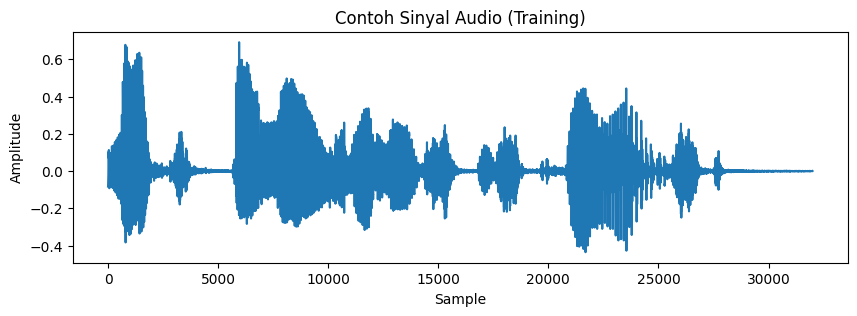

Label: Real


In [15]:
plt.figure(figsize=(10, 3))
plt.plot(X_train[0])
plt.title("Contoh Sinyal Audio (Training)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

print("Label:", "Real" if y_train[0] == 0 else "Fake")

In [16]:
def extract_logmel_spectrogram(
    audio,
    sr=16000,
    n_fft=1024,
    hop_length=256,
    n_mels=64
):
    # STFT → Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )

    # Log scale
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    return log_mel_spec


In [17]:
def process_dataset(X, sr=16000):
    features = []

    for audio in X:
        audio = preprocess_audio(audio, sr)
        logmel = extract_logmel_spectrogram(audio, sr)
        features.append(logmel)

    return np.array(features)


In [18]:
X_train_spec = process_dataset(X_train)
X_val_spec   = process_dataset(X_val)
X_test_spec  = process_dataset(X_test)

print("Train spectrogram shape:", X_train_spec.shape)
print("Validation spectrogram shape:", X_val_spec.shape)
print("Test spectrogram shape:", X_test_spec.shape)

Train spectrogram shape: (13956, 64, 126)
Validation spectrogram shape: (2826, 64, 126)
Test spectrogram shape: (1088, 64, 126)


In [21]:
def prepare_for_cnn(X):
    # X shape: (samples, n_mels, time_frames)
    
    # Normalisasi per dataset
    X = (X - np.min(X)) / (np.max(X) - np.min(X) + 1e-9)
    
    # Tambah channel
    X = X[..., np.newaxis]
    
    return X


In [22]:
X_train_cnn = prepare_for_cnn(X_train_spec)
X_val_cnn   = prepare_for_cnn(X_val_spec)
X_test_cnn  = prepare_for_cnn(X_test_spec)

print("CNN input shape:", X_train_cnn.shape)

CNN input shape: (13956, 64, 126, 1)


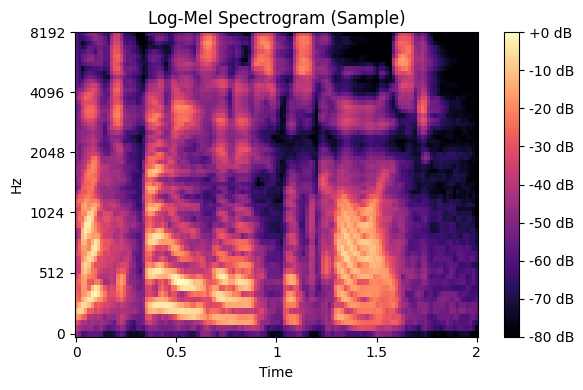

Label: Real


In [23]:
plt.figure(figsize=(6, 4))
librosa.display.specshow(
    X_train_spec[0],
    sr=16000,
    hop_length=256,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title("Log-Mel Spectrogram (Sample)")
plt.tight_layout()
plt.show()

print("Label:", "Real" if y_train[0] == 0 else "Fake")

In [24]:
pip install tensorflow


  Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata (4.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.33.2-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-2.0.1-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached grpcio-1.76.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cach


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout
)
from tensorflow.keras.optimizers import Adam

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [30]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(64, 126, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])


In [31]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 124, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 62, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 60, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 21504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,376,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,399,681 (5.34 MB)

 Trainable params: 1,399,681 (5.34 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=10,
    batch_size=16,
    shuffle=True
)

Epoch 1/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 74s 77ms/step - accuracy: 0.8560 - loss: 0.3139 - val_accuracy: 0.9494 - val_loss: 0.1358
Epoch 2/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 87s 83ms/step - accuracy: 0.9713 - loss: 0.0842 - val_accuracy: 0.9292 - val_loss: 0.1747
Epoch 3/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 93s 96ms/step - accuracy: 0.9832 - loss: 0.0504 - val_accuracy: 0.9883 - val_loss: 0.0404
Epoch 4/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 98s 112ms/step - accuracy: 0.9891 - loss: 0.0346 - val_accuracy: 0.9851 - val_loss: 0.0416
Epoch 5/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 112s 78ms/step - accuracy: 0.9915 - loss: 0.0237 - val_accuracy: 0.9887 - val_loss: 0.0475
Epoch 6/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 71s 82ms/step - accuracy: 0.9937 - loss: 0.0178 - val_accuracy: 0.9862 - val_loss: 0.0581
Epoch 7/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 109s 113ms/step - accuracy: 0.9912 - loss: 0.0237 - val_accuracy: 0.9795 - val_loss: 0.0624
Epoch 8/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 142s 113ms/step - accuracy: 0.9965 - loss: 0.0

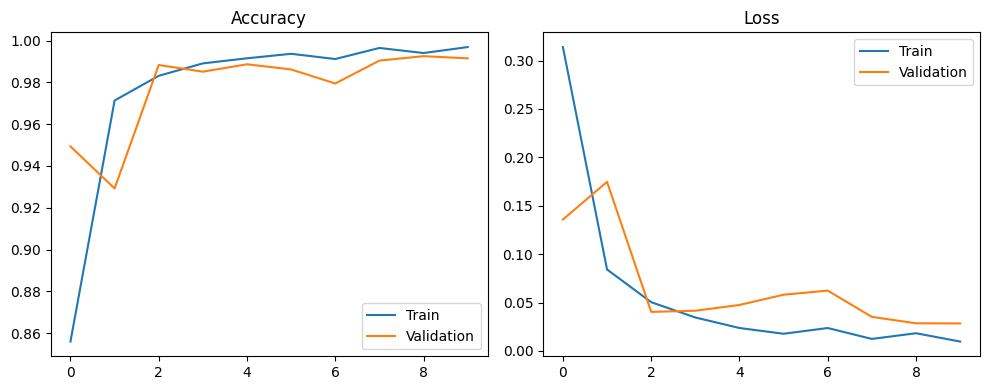

In [34]:
plt.figure(figsize=(10, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 0.8640
Test Loss     : 0.4043


In [36]:
y_pred_prob = model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step


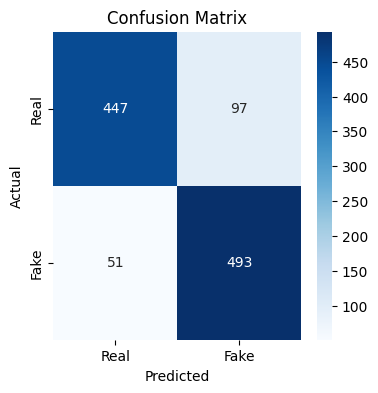

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [38]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Real", "Fake"]
))

              precision    recall  f1-score   support

        Real       0.90      0.82      0.86       544
        Fake       0.84      0.91      0.87       544

    accuracy                           0.86      1088
   macro avg       0.87      0.86      0.86      1088
weighted avg       0.87      0.86      0.86      1088

